# 군집화 3개 모델 비교 — K-Means · GMM · DBSCAN

Iris(붓꽃) 데이터셋을 동일한 조건으로 K-Means, GMM(Gaussian Mixture Model), DBSCAN 세 가지 군집화 알고리즘에 학습시키고, 실제 품종(target)과의 일치도 및 실루엣 계수(Silhouette Score)로 비교한다.


In [12]:
# 데이터프레임 처리를 위한 pandas
import pandas as pd
# 수치 연산을 위한 numpy
import numpy as np
# 군집 결과 시각화를 위한 matplotlib
import matplotlib.pyplot as plt
# 실습용 표준 데이터셋(Iris)을 불러오기 위한 함수
from sklearn.datasets import load_iris
# 군집화 모델 1: K-Means
from sklearn.cluster import KMeans
# 군집화 모델 2: Gaussian Mixture Model(GMM)
from sklearn.mixture import GaussianMixture
# 군집화 모델 3: DBSCAN (밀도 기반)
from sklearn.cluster import DBSCAN
# 군집 결과를 2차원으로 압축해 시각화하기 위한 PCA
from sklearn.decomposition import PCA
# 군집화 품질을 정량적으로 평가하기 위한 실루엣 계수
from sklearn.metrics import silhouette_score
# 노트북 안에서 그래프를 바로 표시하기 위한 매직 명령어
%matplotlib inline

# 각 파트(단계)별 시작/종료 시각 기록을 위한 datetime
import datetime

print(datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'))

# 현재 시각을 'yyyy-mm-dd HH:MI:SS'(24시간제) 형식 문자열로 반환하는 헬퍼 함수
def now_str():
    return datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')


2026-08-31 11:06:47


In [13]:
# [파트1. 데이터 로드] 시작 시각 기록
_part1_start = now_str()
print(f'[파트1. 데이터 로드] 시작 시각: {_part1_start}')

# sklearn에 내장된 Iris(붓꽃) 데이터셋을 불러온다
iris = load_iris()
# 4개 피처(꽃받침 길이/너비, 꽃잎 길이/너비)에 이름을 붙인다
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
# 넘파이 배열을 다루기 편한 DataFrame 형태로 변환한다
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
# 실제 품종 라벨(0, 1, 2)을 target 컬럼으로 추가한다 — 군집화 결과와 비교할 정답으로만 사용
irisDF['target'] = iris.target
# 데이터가 잘 로드됐는지 상위 3개 행을 확인한다
display(irisDF.head(3))

# [파트1. 데이터 로드] 종료 시각 기록
_part1_end = now_str()
print(f'[파트1. 데이터 로드] 종료 시각: {_part1_end}')


[파트1. 데이터 로드] 시작 시각: 2026-08-31 11:06:47


,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


[파트1. 데이터 로드] 종료 시각: 2026-08-31 11:06:47


In [14]:
# [파트2. K-Means 학습] 시작 시각 기록
_part2_start = now_str()
print(f'[파트2. K-Means 학습] 시작 시각: {_part2_start}')

# K-Means 모델을 정의한다 — 군집 개수 3개, 중심점 초기화 방식은 k-means++, 최대 반복 300회
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
# 4개 피처 데이터로 학습하고, 각 데이터가 속한 군집 번호(0~2)를 바로 반환받는다
kmeans_labels = kmeans.fit_predict(iris.data)
# 예측된 군집 번호를 DataFrame에 kmeans_cluster 컬럼으로 저장한다
irisDF['kmeans_cluster'] = kmeans_labels

# [파트2. K-Means 학습] 종료 시각 기록
_part2_end = now_str()
print(f'[파트2. K-Means 학습] 종료 시각: {_part2_end}')


[파트2. K-Means 학습] 시작 시각: 2026-08-31 11:06:47
[파트2. K-Means 학습] 종료 시각: 2026-08-31 11:06:47


c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [15]:
# [파트3. GMM 학습] 시작 시각 기록
_part3_start = now_str()
print(f'[파트3. GMM 학습] 시작 시각: {_part3_start}')

# GMM 모델을 정의한다 — 데이터가 3개의 정규분포(가우시안)에서 생성됐다고 가정한다
gmm = GaussianMixture(n_components=3, random_state=0)
# 4개 피처 데이터로 학습하고, 각 데이터가 속할 확률이 가장 높은 군집 번호를 반환받는다
gmm_labels = gmm.fit(iris.data).predict(iris.data)
# 예측된 군집 번호를 DataFrame에 gmm_cluster 컬럼으로 저장한다
irisDF['gmm_cluster'] = gmm_labels

# [파트3. GMM 학습] 종료 시각 기록
_part3_end = now_str()
print(f'[파트3. GMM 학습] 종료 시각: {_part3_end}')


[파트3. GMM 학습] 시작 시각: 2026-08-31 11:06:47
[파트3. GMM 학습] 종료 시각: 2026-08-31 11:06:47


c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [16]:
# [파트4. DBSCAN 학습] 시작 시각 기록
_part4_start = now_str()
print(f'[파트4. DBSCAN 학습] 시작 시각: {_part4_start}')

# DBSCAN 모델을 정의한다 — 반경(eps) 0.6 안에 8개 이상의 이웃이 있어야 하나의 군집으로 인정한다
dbscan = DBSCAN(eps=0.6, min_samples=8, metric='euclidean')
# 4개 피처 데이터로 학습과 동시에 군집 번호를 반환받는다 — 군집에 못 낀 점은 -1(노이즈)로 표시된다
dbscan_labels = dbscan.fit_predict(iris.data)
# 예측된 군집 번호를 DataFrame에 dbscan_cluster 컬럼으로 저장한다
irisDF['dbscan_cluster'] = dbscan_labels

# [파트4. DBSCAN 학습] 종료 시각 기록
_part4_end = now_str()
print(f'[파트4. DBSCAN 학습] 종료 시각: {_part4_end}')


[파트4. DBSCAN 학습] 시작 시각: 2026-08-31 11:06:47
[파트4. DBSCAN 학습] 종료 시각: 2026-08-31 11:06:47


In [17]:
# [파트5. 교차 집계 비교] 시작 시각 기록
_part5_start = now_str()
print(f'[파트5. 교차 집계 비교] 시작 시각: {_part5_start}')

# K-Means 결과와 실제 품종을 교차 집계해서 출력한다
print('### K-Means ###')
print(irisDF.groupby('target')['kmeans_cluster'].value_counts())

# GMM 결과와 실제 품종을 교차 집계해서 출력한다
print('\n### GMM ###')
print(irisDF.groupby('target')['gmm_cluster'].value_counts())

# DBSCAN 결과와 실제 품종을 교차 집계해서 출력한다 (-1은 군집에 속하지 못한 노이즈)
print('\n### DBSCAN ###')
print(irisDF.groupby('target')['dbscan_cluster'].value_counts())

# [파트5. 교차 집계 비교] 종료 시각 기록
_part5_end = now_str()
print(f'\n[파트5. 교차 집계 비교] 종료 시각: {_part5_end}')


[파트5. 교차 집계 비교] 시작 시각: 2026-08-31 11:06:47
### K-Means ###
target  kmeans_cluster
0       1                 50
1       0                 47
        2                  3
2       2                 36
        0                 14
Name: count, dtype: int64

### GMM ###
target  gmm_cluster
0       1              50
1       0              45
        2               5
2       2              50
Name: count, dtype: int64

### DBSCAN ###
target  dbscan_cluster
0        0                49
        -1                 1
1        1                46
        -1                 4
2        1                42
        -1                 8
Name: count, dtype: int64

[파트5. 교차 집계 비교] 종료 시각: 2026-08-31 11:06:47


In [18]:
# [파트6. 실루엣 계수 계산] 시작 시각 기록
_part6_start = now_str()
print(f'[파트6. 실루엣 계수 계산] 시작 시각: {_part6_start}')

# K-Means 군집 결과의 실루엣 계수를 계산한다 — 1에 가까울수록 군집이 잘 나뉜 것
kmeans_silhouette = silhouette_score(iris.data, kmeans_labels)
# GMM 군집 결과의 실루엣 계수를 계산한다
gmm_silhouette = silhouette_score(iris.data, gmm_labels)
# DBSCAN 군집 결과의 실루엣 계수를 계산한다 (-1 노이즈도 하나의 군집처럼 포함해서 계산)
dbscan_silhouette = silhouette_score(iris.data, dbscan_labels)

# 세 모델의 실루엣 계수를 하나의 표로 정리한다
silhouette_df = pd.DataFrame({
    '모델': ['K-Means', 'GMM', 'DBSCAN'],
    'silhouette_score': [kmeans_silhouette, gmm_silhouette, dbscan_silhouette],
})
# 비교 결과를 출력한다
print(silhouette_df.to_string(index=False))

# [파트6. 실루엣 계수 계산] 종료 시각 기록
_part6_end = now_str()
print(f'\n[파트6. 실루엣 계수 계산] 종료 시각: {_part6_end}')


[파트6. 실루엣 계수 계산] 시작 시각: 2026-08-31 11:06:47
     모델  silhouette_score
K-Means          0.551192
    GMM          0.501176
 DBSCAN          0.542120

[파트6. 실루엣 계수 계산] 종료 시각: 2026-08-31 11:06:47


[파트7. PCA 2차원 시각화] 시작 시각: 2026-08-31 11:06:47


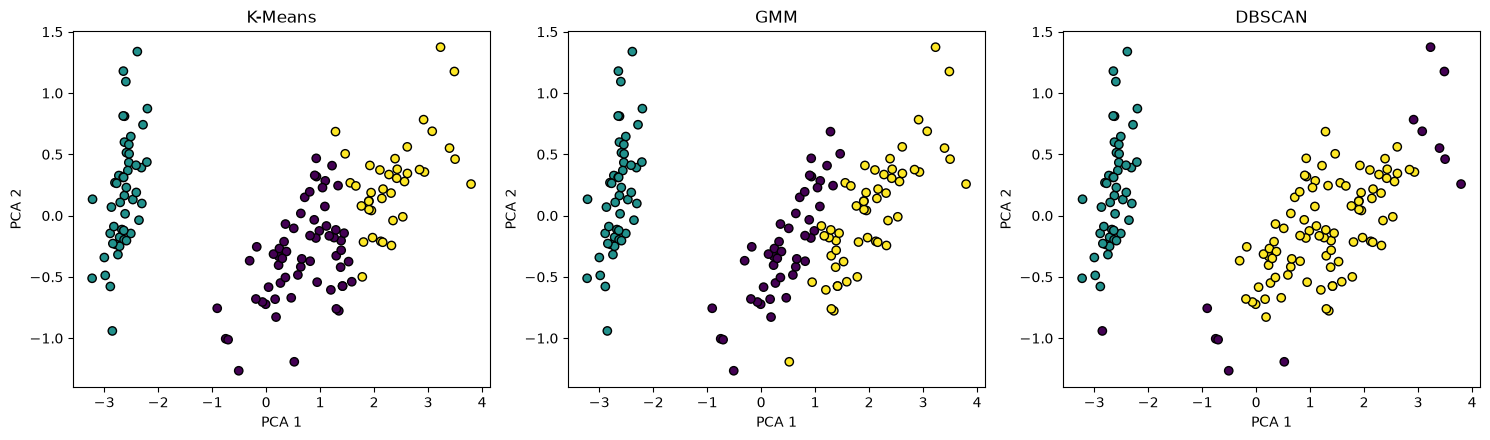

[파트7. PCA 2차원 시각화] 종료 시각: 2026-08-31 11:06:47


In [19]:
# [파트7. PCA 2차원 시각화] 시작 시각 기록
_part7_start = now_str()
print(f'[파트7. PCA 2차원 시각화] 시작 시각: {_part7_start}')

# 4차원 피처를 2차원으로 압축해 눈으로 비교할 수 있게 한다
pca = PCA(n_components=2, random_state=0)
# 4개 피처 데이터를 2개 축(pca_x, pca_y)으로 변환한다
pca_transformed = pca.fit_transform(iris.data)
# 변환된 첫 번째 축 좌표를 DataFrame에 pca_x 컬럼으로 저장한다
irisDF['pca_x'] = pca_transformed[:, 0]
# 변환된 두 번째 축 좌표를 DataFrame에 pca_y 컬럼으로 저장한다
irisDF['pca_y'] = pca_transformed[:, 1]

# 한 화면에 3개 그래프(K-Means, GMM, DBSCAN)를 나란히 그리기 위한 subplot을 준비한다
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
# 비교할 (컬럼명, 그래프 제목) 목록을 정의한다
cluster_cols = [('kmeans_cluster', 'K-Means'), ('gmm_cluster', 'GMM'), ('dbscan_cluster', 'DBSCAN')]

# 3개 모델을 순서대로 순회하며 산점도를 그린다
for ax, (col, title) in zip(axes, cluster_cols):
    # 군집 번호별로 색을 다르게 표시하며 산점도를 그린다
    ax.scatter(irisDF['pca_x'], irisDF['pca_y'], c=irisDF[col], cmap='viridis', edgecolor='k')
    # 그래프 제목을 모델 이름으로 지정한다
    ax.set_title(title)
    # x축 이름을 지정한다
    ax.set_xlabel('PCA 1')
    # y축 이름을 지정한다
    ax.set_ylabel('PCA 2')

# 그래프 사이 간격을 자동으로 맞춘다
plt.tight_layout()
# 완성된 그래프를 화면에 출력한다
plt.show()

# [파트7. PCA 2차원 시각화] 종료 시각 기록
_part7_end = now_str()
print(f'[파트7. PCA 2차원 시각화] 종료 시각: {_part7_end}')
